# Fine-Tuning et Transfer Learning en NLP avec Keras 3 et KerasNLP  
## Génération de Programmes Sportifs avec GPT-2 sur le Corpus TrAIn.me

## Objectifs de ce notebook

Dans ce notebook, nous allons explorer le **fine-tuning** et le **transfer learning** pour adapter GPT-2 à un contexte métier spécifique :  
la **génération de programmes sportifs personnalisés** pour le projet **TrAIn.me**.

Ce que nous allons apprendre :

1. **Comprendre le Transfer Learning** → Réutiliser les connaissances pré-entraînées du GPT-2 généraliste.  
2. **Utiliser KerasNLP** → Une API moderne, intégrée, et optimisée pour le NLP.  
3. **Charger GPT-2 via KerasNLP** → Modèle pré-entraîné prêt pour le fine-tuning.  
4. **Adapter GPT-2 au domaine du coaching sportif** → Utiliser nos propres textes nettoyés (échauffements, séances, finishers, conseils).  
5. **Génération conditionnelle** → Produire automatiquement des programmes sportifs cohérents selon un prompt (niveau, objectif, durée…).

Nous allons travailler avec le **corpus TrAIn.me**, constitué d’exemples réels de coaching, de descriptions d’exercices et de structures de séances.

## Pourquoi Keras 3 et KerasNLP ?

**Keras 3** (2023+) apporte :  
- **Multi-backend** : TensorFlow, JAX ou PyTorch  
- **Performances optimisées** : compilation XLA  
- **API moderne** : pipeline clair et cohérent  

**KerasNLP** offre :  
- **Modèles pré-entraînés** : GPT-2, BERT, T5…  
- **Tokenizers intégrés** : compatibles avec les modèles HF  
- **Pipeline simplifié** : de la tokenisation à la génération  
- **Fine-tuning facile** : API haut niveau et flexible  

## Concepts clés que nous allons explorer

- **Modèles pré-entraînés** : GPT-2 via KerasNLP  
- **Feature Extraction** : Utiliser les représentations existantes  
- **Fine-Tuning complet** : Ajuster tous les poids du modèle  
- **Freezing vs Unfreezing** : Influence sur l’apprentissage  
- **Génération conditionnelle** : Personnalisation des programmes  

## Architecture du notebook

```
Installation → KerasNLP GPT-2 → Exploration "program_summary.csv" → Baseline (frozen) → Fine-tuning → Comparaison → Génération
```

## 1. Installation et Configuration

Dans cette première section, nous configurons l’environnement technique pour le fine-tuning de **GPT-2** en mode **PyTorch-only** dans le cadre du projet **TrAIn.me** :

- Forcer `transformers` à utiliser **uniquement PyTorch** (pas de TensorFlow / Flax).
- Importer les bibliothèques Python classiques pour l’analyse et la visualisation.
- Charger **PyTorch** et **Transformers**.
- Vérifier la disponibilité de **CUDA** pour exploiter le GPU si possible.
- Afficher les versions clés utilisées pour assurer la reproductibilité.
- Configurer le style graphique pour les futures visualisations.

À l’issue de cette cellule, le notebook est prêt à charger GPT-2 et à l’adapter à notre corpus de textes de coaching sportif.


## Imports

In [ ]:
# Bibliothèques principales
import os
from pathlib import Path
from IPython.display import clear_output
import warnings
import textwrap

# Imports Python / data science classiques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub


# === PyTorch + Transformers (UNIQUEMENT côté Torch) ===
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM

## Configuration

In [89]:
# === Config pour forcer Transformers en mode PyTorch-only ===
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

warnings.filterwarnings("ignore")

# Détection GPU / CPU
cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"

print("CUDA dispo (torch) ?", cuda_available)

print("\nVersions :")
print(f"  - Torch        : {torch.__version__}")
print(f"  - Transformers : {transformers.__version__}")
print(f"  - Device used  : {device}")

# Reproductibilité minimale
torch.manual_seed(42)
if cuda_available:
    torch.cuda.manual_seed_all(42)

# Config graphiques
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Config Torch
device = "cuda" if torch.cuda.is_available() else "cpu"

print("\nNotebook GPT-2 configuré en mode PyTorch-only pour TrAIn.me (Transformers sans TensorFlow).")

CUDA dispo (torch) ? False

Versions :
  - Torch        : 2.9.1+cpu
  - Transformers : 4.57.3
  - Device used  : cpu

Notebook GPT-2 configuré en mode PyTorch-only pour TrAIn.me (Transformers sans TensorFlow).


## Header expérimental

In [ ]:
OUTPUT_MODEL_NAME = "fine_tuning_gpt2_v4"

# Longueur des séquences
MAX_LENGTH = 128 # On garde 128 pour rester CPU-friendly
# Batch & split
BATCH_SIZE = 8 # Plus petit batch → gradients plus stables sur CPU
TRAIN_RATIO = 0.85 # 85% train, 15% validation
TOTAL_SAMPLES = 1596
 
NUM_TRAIN_SAMPLES = int(TOTAL_SAMPLES * TRAIN_RATIO)
NUM_VAL_SAMPLES = TOTAL_SAMPLES - NUM_TRAIN_SAMPLES
 
print(f"Train samples : {NUM_TRAIN_SAMPLES} | Val samples : {NUM_VAL_SAMPLES}")

# Hyperparamètres FROZEN (baseline rapide)
EPOCHS_FROZEN = 3
LR_FROZEN = 5e-4

# Hyperparamètres FULL FINE-TUNING (backbone dégelé)
EPOCHS_FULL = 4
LR_FULL = 5e-5

Train samples : 1356 | Val samples : 240


## 2. Comprendre le Transfer Learning

### 2.1 Qu’est-ce que le Transfer Learning ?

Le transfer learning consiste à **réutiliser les connaissances** d’un modèle pré-entraîné — ici **GPT-2** — pour l’adapter à une nouvelle tâche spécialisée :  
la génération de **programmes sportifs personnalisés** pour TrAIn.me.

GPT-2 a déjà appris :
- la structure de la langue,
- la cohérence des phrases,
- la logique de progression d’un texte.

Notre rôle est d’adapter ces compétences générales à un domaine précis :  
**échauffements, séances structurées, intensités, objectifs, contraintes utilisateur**.

#### Analogie : Un coach expérimenté qui change de discipline

Un coach formé en musculation comprend déjà :
- l’anatomie,
- la logique des séries et charges,
- la progression.

S’il commence à coacher en HIIT :
- **Pré-entraînement** : son expertise générale du sport,
- **Transfer Learning** : il transpose ses connaissances vers une nouvelle activité,
- **Fine-Tuning** : il ajuste sa méthode aux exigences spécifiques d’un entraînement HIIT.

### 2.2 Les deux approches principales

#### Feature Extraction (Frozen)
```
GPT-2 pré-entraîné → [FREEZE] → Ajout d’un petit module → Entraînement seulement du module ajouté
```
- **Avantages** : rapide, peu coûteux, utile quand le corpus métier est limité.  
- **Limites** : le modèle reste trop “générique” et ne maîtrise pas les structures propres au coaching.

#### Fine-Tuning (Unfrozen)
```
GPT-2 pré-entraîné → [UNFREEZE] → Ajustement de tous les poids → Learning rate très faible
```
- **Avantages** : meilleure adaptation au vocabulaire sportif, aux consignes, aux enchaînements d’exercices.  
- **Inconvénients** : plus long à entraîner, plus sensible à l’overfitting.

Pour TrAIn.me, c’est cette approche qui donnera le **meilleur style coaching** et la **meilleure cohérence des programmes**.

### 2.3 Visualisation du Transfer Learning
```
GPT-2 généraliste → Adaptation → GPT-2 TrAIn.me (coaching sportif)
```

Le modèle initial comprend déjà “comment écrire”. 

Le fine-tuning lui apprend désormais “quoi écrire” dans un contexte **sport, intensité, niveau, objectifs**.

### 2.4 Visualisation des stratégies de Transfer Learning

La figure suivante illustre les trois grandes stratégies possibles lorsqu’on souhaite adapter un modèle pré-entraîné comme **GPT-2** à une nouvelle tâche — ici la génération de programmes sportifs pour TrAIn.me.

- **Entraînement from scratch** : impossible dans notre contexte, car il faudrait des milliards de tokens pour obtenir un modèle cohérent.  
- **Feature Extraction** : GPT-2 reste figé et seules quelques couches ajoutées apprennent. C’est rapide, mais le modèle reste très générique.  
- **Fine-Tuning complet** : toutes les couches de GPT-2 sont ajustées avec un *learning rate* faible, ce qui permet d’intégrer vraiment le vocabulaire et les structures de coaching.

Cette visualisation nous permet de bien comprendre pourquoi le fine-tuning complet est plus adapté pour capter les nuances d’un programme sportif (enchaînements, intensité, niveau, transitions d’exercices).


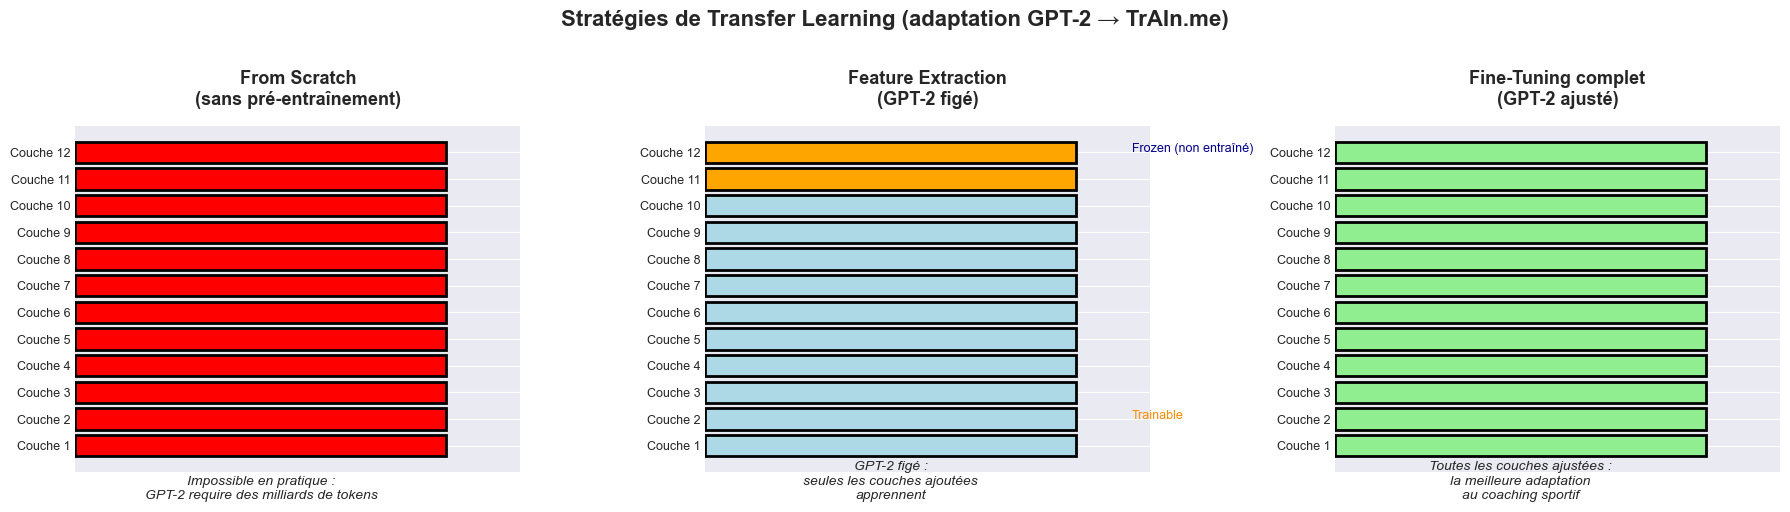


Pour le projet TrAIn.me, nous utiliserons principalement le fine-tuning complet afin d'adapter GPT-2 au vocabulaire et aux structures des programmes sportifs.


In [91]:
# Visualisation des stratégies de transfer learning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategies = [
    ("From Scratch\n(sans pré-entraînement)", 
     ['red'] * 12, 
     "Impossible en pratique :\nGPT-2 require des milliards de tokens"),
    
    ("Feature Extraction\n(GPT-2 figé)", 
     ['lightblue'] * 10 + ['orange'] * 2, 
     "GPT-2 figé :\nseules les couches ajoutées\napprennent"),
    
    ("Fine-Tuning complet\n(GPT-2 ajusté)", 
     ['lightgreen'] * 12, 
     "Toutes les couches ajustées :\nla meilleure adaptation\nau coaching sportif")
]

for idx, (title, colors, desc) in enumerate(strategies):
    ax = axes[idx]
    
    # Dessiner les couches (barres horizontales)
    for i, color in enumerate(colors):
        ax.barh(i, 1, color=color, edgecolor='black', linewidth=2)
    
    ax.set_ylim(-1, 12)
    ax.set_xlim(0, 1.2)
    ax.set_yticks(range(12))
    ax.set_yticklabels([f'Couche {i+1}' for i in range(12)], fontsize=9)
    ax.set_xticks([])
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.text(0.5, -2, desc, ha='center', fontsize=10, style='italic')
    
    # Légende pour la colonne intermédiaire
    if idx == 1:
        ax.text(1.15, 11, 'Frozen (non entraîné)', fontsize=9, color='darkblue')
        ax.text(1.15, 1, 'Trainable', fontsize=9, color='darkorange')

plt.suptitle("Stratégies de Transfer Learning (adaptation GPT-2 → TrAIn.me)", 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("\nPour le projet TrAIn.me, nous utiliserons principalement le fine-tuning complet afin d'adapter GPT-2 au vocabulaire et aux structures des programmes sportifs.")


## 3. Chargement du Modèle Pré-entraîné : GPT-2 (Transformers – PyTorch)

### 3.1 Pourquoi GPT-2 pour TrAIn.me ?

**GPT-2** est un modèle de génération de texte particulièrement adapté au projet TrAIn.me.  
Il possède déjà une connaissance profonde de la syntaxe, de la cohérence textuelle et des structures narratives.  
Notre objectif : **adapter cette base générale** pour générer des programmes sportifs personnalisés (échauffements, séances structurées, finishers, conseils…).

Caractéristiques essentielles de la version *gpt2* :
- ~ **124M paramètres**
- Pré-entraînement massif sur **WebText (~40 Go de texte)**
- Architecture **decoder-only** optimisée pour la génération
- Fonctionnement **auto-régressif** (prédire le token suivant)

Avec la librairie **Transformers (HuggingFace)** :
- Chargement du tokenizer en 1 ligne : `AutoTokenizer.from_pretrained("gpt2")`
- Chargement du modèle : `AutoModelForCausalLM.from_pretrained("gpt2")`
- API puissante pour la génération (`model.generate`)
- Compatible CPU / GPU
- Fine-tuning entièrement personnalisable en PyTorch

### 3.2 Architecture GPT-2
```
Texte → Tokenizer → Embeddings → [12 blocs Transformer] → Tête LM → Token suivant
```


Chaque bloc Transformer inclut :
- Multi-Head Self-Attention  
- MLP (Feed-Forward Network)  
- LayerNorm  
- Residual Connections  

Dans le cadre TrAIn.me, nous allons fine-tuner cette architecture afin qu’elle apprenne **le style, le vocabulaire et la logique des programmes sportifs**.

In [92]:
print("Chargement du modèle GPT-2 (Transformers – HuggingFace)...")
print("   (Téléchargement possible lors de la première exécution)\n")

# Nom du preset GPT-2 utilisé pour TrAIn.me
INPUT_MODEL_NAME = "gpt2"   # version standard (~124M paramètres)

# === Chargement du tokenizer ===
tokenizer = AutoTokenizer.from_pretrained(INPUT_MODEL_NAME)

# GPT-2 n’a pas toujours de padding → on utilise le token EOS comme pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# === Chargement du modèle pré-entraîné ===
gpt2_model = AutoModelForCausalLM.from_pretrained(INPUT_MODEL_NAME)

# Sélection CPU / GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
gpt2_model = gpt2_model.to(device)

print("GPT-2 et tokenizer chargés avec succès !\n")

# === Infos structurelles du modèle ===
print("Structure du modèle GPT-2 :")
print(f"  - Modèle chargé     : {INPUT_MODEL_NAME}")
print(f"  - Taille vocabulaire : {len(tokenizer)} tokens")
print(f"  - Max length théorique : 1024 tokens (config standard)")

# Nombre de paramètres entraînables
total_params = sum(p.numel() for p in gpt2_model.parameters() if p.requires_grad)
size_mb = total_params * 4 / (1024**2)

print(f"\n  - Paramètres entraînables : {total_params:,}")
print(f"  - Taille mémoire approx.  : {size_mb:.1f} MB")

print("\nGPT-2 a été entraîné sur un corpus massif.")
print("   Nous allons maintenant l’adapter au domaine du coaching sportif pour TrAIn.me.")


Chargement du modèle GPT-2 (Transformers – HuggingFace)...
   (Téléchargement possible lors de la première exécution)

GPT-2 et tokenizer chargés avec succès !

Structure du modèle GPT-2 :
  - Modèle chargé     : gpt2
  - Taille vocabulaire : 50257 tokens
  - Max length théorique : 1024 tokens (config standard)

  - Paramètres entraînables : 124,439,808
  - Taille mémoire approx.  : 474.7 MB

GPT-2 a été entraîné sur un corpus massif.
   Nous allons maintenant l’adapter au domaine du coaching sportif pour TrAIn.me.


### 3.3 Test du tokenizer (Transformers – HuggingFace)

Avant de préparer les données pour le fine-tuning, nous testons rapidement le **tokenizer GPT-2** afin de vérifier :

- la manière dont il convertit un texte sportif en tokens,
- la cohérence des IDs générés,
- la reconstruction inverse (decode),
- et la présence correcte du token EOS utilisé comme padding.

Ce test nous permet de valider que le tokenizer est fonctionnel et prêt à transformer notre futur corpus TrAIn.me (exercices, échauffements, programmes). 


In [93]:
print("Test du tokenizer GPT-2 (Transformers – HuggingFace)\n")
print("=" * 80)

# Texte de test (version coaching sportif)
test_text = "Effectue 3 séries de 12 squats avec une bonne amplitude."
print(f"Texte original : {test_text}\n")

# --- Tokenisation ---
tokens = tokenizer.encode(test_text, add_special_tokens=False)
print(f"Tokens (IDs)   : {tokens}")

# --- Dé-tokenisation ---
decoded_text = tokenizer.decode(tokens)
print(f"Décodage       : {decoded_text}")

# --- Analyse token par token ---
print("\nTokens individuels :")
for i, token_id in enumerate(tokens):
    token_str = tokenizer.decode([token_id])
    print(f"  {i}: {token_id:5d} → '{token_str}'")

print("\n" + "=" * 80)

Test du tokenizer GPT-2 (Transformers – HuggingFace)

Texte original : Effectue 3 séries de 12 squats avec une bonne amplitude.

Tokens (IDs)   : [18610, 518, 513, 264, 2634, 1678, 390, 1105, 48871, 257, 35138, 17809, 5351, 710, 37188, 13]
Décodage       : Effectue 3 séries de 12 squats avec une bonne amplitude.

Tokens individuels :
  0: 18610 → 'Effect'
  1:   518 → 'ue'
  2:   513 → ' 3'
  3:   264 → ' s'
  4:  2634 → 'é'
  5:  1678 → 'ries'
  6:   390 → ' de'
  7:  1105 → ' 12'
  8: 48871 → ' squats'
  9:   257 → ' a'
  10: 35138 → 'vec'
  11: 17809 → ' une'
  12:  5351 → ' bon'
  13:   710 → 'ne'
  14: 37188 → ' amplitude'
  15:    13 → '.'



### 3.4 Test de génération avec le modèle pré-entraîné (avant fine-tuning)

Avant d’entraîner GPT-2 sur notre corpus sportif, il est utile d’observer son comportement “brut”.  
Ce test de génération permet de visualiser :

- la qualité du modèle pré-entraîné,
- son style général (non spécialisé),
- sa capacité à continuer une phrase sportive,
- les limites avant adaptation au domaine TrAIn.me.

Cette étape sert de **baseline** : elle nous permet de comparer, plus tard, la différence qualitative entre  
→ GPT-2 “vanilla”  
et  
→ GPT-2 fine-tuné sur des programmes sportifs.


In [94]:
def generate_text_gpt2(model, tokenizer, prompt, max_length=60, temperature=1.0, num_samples=1):
    """
    Génère du texte avec GPT-2 (HuggingFace Transformers).

    Args:
        model: AutoModelForCausalLM GPT-2 (HF)
        tokenizer: AutoTokenizer GPT-2
        prompt: texte de départ
        max_length: longueur maximale de génération (tokens)
        temperature: contrôle la créativité
        num_samples: nombre d’échantillons à générer
    """
    results = []

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

    for _ in range(num_samples):
        output = model.generate(
            input_ids,
            max_length=max_length,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

        text = tokenizer.decode(output[0], skip_special_tokens=True)
        results.append(text)

    return results


# Test du modèle pré-entraîné (AVANT fine-tuning)
print("Test du modèle GPT-2 AVANT fine-tuning\n")
print("="*80)

# Prompts adaptés au domaine sportif
test_prompts = [
    "Start your warm-up with", #"Commence ton échauffement par",
    "For a full-body workout, perform", #"Pour un entraînement full body, réalise",
    "To improve your cardio, try to", #"Pour améliorer ton cardio, essaie de",
]

for prompt in test_prompts:
    print(f"\nPrompt: '{prompt}'")
    generated = generate_text_gpt2(gpt2_model, tokenizer, prompt, max_length=60)
    print(f"> Généré: {generated[0]}")
    print("-"*80)

print("\nLe modèle produit un texte cohérent mais générique.")
print("   Après fine-tuning, il adoptera un style plus sportif et adapté au coaching TrAIn.me.")


Test du modèle GPT-2 AVANT fine-tuning


Prompt: 'Start your warm-up with'
> Généré: Start your warm-up with some hot water to create your warm-up look:

Fill the top of the warm-up with cold water.

Place the top of the warm-up on top of your hands.

Breathe deeply into the top of the warm-
--------------------------------------------------------------------------------

Prompt: 'For a full-body workout, perform'
> Généré: For a full-body workout, perform each workout with a single (or four) sets of eight reps.

If you're not going to have any additional rep sets, keep in mind that your goal is to get the heaviest, strongest, and heaviest movements possible. If you're going to
--------------------------------------------------------------------------------

Prompt: 'To improve your cardio, try to'
> Généré: To improve your cardio, try to do a few sets of 4-5 reps of each rep.

The hardest part of the workout is getting to the point where it's time to do the next set of reps, but to do

## 4. Chargement et Exploration du Dataset TrAIn.me

### 4.1 Le Dataset “program_summary.csv”

Dans cette section, nous allons charger et explorer le fichier **program_summary.csv**, qui constitue notre corpus principal pour le fine-tuning de GPT-2.

Ce fichier contient des **descriptions d’exercices et d’exécutions**, entièrement en anglais, et représente une base idéale pour apprendre au modèle :

- le vocabulaire spécifique du coaching sportif,
- la structure des consignes d’exécution,
- les formulations types utilisées dans les programmes d’entraînement,
- la logique technique propre aux mouvements (amplitude, position, respiration, tempo, muscles ciblés).

**Caractéristiques du dataset :**
- Descriptions précises d’exercices (1 à 3 phrases en moyenne)
- Données textuelles 100 % en anglais
- Bon mélange d’instructions biomécaniques, de conseils de forme et d’indications techniques
- Corpus parfaitement adapté à un modèle génératif spécialisé “coach sportif”

**Notre utilisation :**  
Nous n’utiliserons pas ce dataset pour de la classification ou du scoring, mais **uniquement pour entraîner GPT-2 à générer des descriptions et programmes sportifs cohérents**.


In [ ]:
print("Chargement du corpus TrAIn.me (program_summary.csv)...\n")

# Téléchargement automatique du dataset Kaggle
path = kagglehub.dataset_download(
    "adnanelouardi/600k-fitness-exercise-and-workout-program-dataset"
)

print("Dataset téléchargé avec succès !")
print("Chemin local :", path, "\n")

# Conversion du chemin KaggleHub → Path
dataset_dir = Path(path)

# Fichier CSV principal (structure confirmée dans le dataset Kaggle)
csv_path = dataset_dir / "program_summary.csv"

print(f"Lecture du fichier : {csv_path.name}\n")

# Chargement du corpus fusionné
df = pd.read_csv(csv_path)

print("Dataset chargé !\n")
print("Structure du dataset :")
print(f"  - Nombre total de lignes : {len(df)}")
print(f"  - Colonnes : {list(df.columns)}")

# Explorer quelques exemples
print("\nExemples de descriptions d'exercices :\n")
print("="*80)

sample_rows = df.sample(3, random_state=42)

for idx, row in sample_rows.iterrows():
    description = str(row.get("description", "")).strip()
    name = str(row.get("title", "Unknown Exercise"))

    print(f"\nExemple #{idx}")
    print(f"Nom de l'exercice : {name}")
    print(f"Longueur : {len(description.split())} mots")

    # Aperçu des 200 premiers caractères
    preview = description[:200] + "..."
    wrapped_text = textwrap.fill(preview, width=75)
    print(f"\nTexte :\n{wrapped_text}")
    print("-"*80)


Chargement du dataset TrAIn.me (program_summary.csv)...

Dataset chargé !

Structure du dataset :
  - Nombre total de lignes : 2598
  - Colonnes : ['title', 'description', 'level', 'goal', 'equipment', 'program_length', 'time_per_workout', 'total_exercises', 'created', 'last_edit']

Exemples de descriptions d'exercices :


Exemple #211
Nom de l'exercice : 6 Day Powerbuilding (Base+Peak)
Longueur : 68 mots

Texte :
Introducing my 13-Week Powerbuilding Program: The ultimate training plan
designed for serious lifters who want to build muscle, increase strength,
and crush their 1-rep max on the bench press, squat, ...
--------------------------------------------------------------------------------

Exemple #2124
Nom de l'exercice : Strength and hypertrophy basic powerbuilding
Longueur : 17 mots

Texte :
This program aims to provide the basics of powerbuilding for beginner and
intermediate powerlifters in the offseason...
---------------------------------------------------------------------

### 4.2 Statistiques et distribution

Dans cette section, nous allons analyser rapidement la structure statistique du dataset **program_summary.csv**.  
L’objectif est de mieux comprendre le contenu textuel avant de préparer le corpus pour le fine-tuning de GPT-2.

Nous allons notamment observer :

- la longueur des descriptions d’exercices (en nombre de mots),
- la distribution générale des textes,
- la présence éventuelle de valeurs manquantes,
- la variabilité entre les différents mouvements et instructions.

Cette analyse permet d’ajuster les paramètres du modèle (longueur maximale des séquences, taille des batches, stratégie de découpage) et d’anticiper la qualité du futur fine-tuning sur le domaine sportif.


Analyse des longueurs et distribution du corpus TrAIn.me



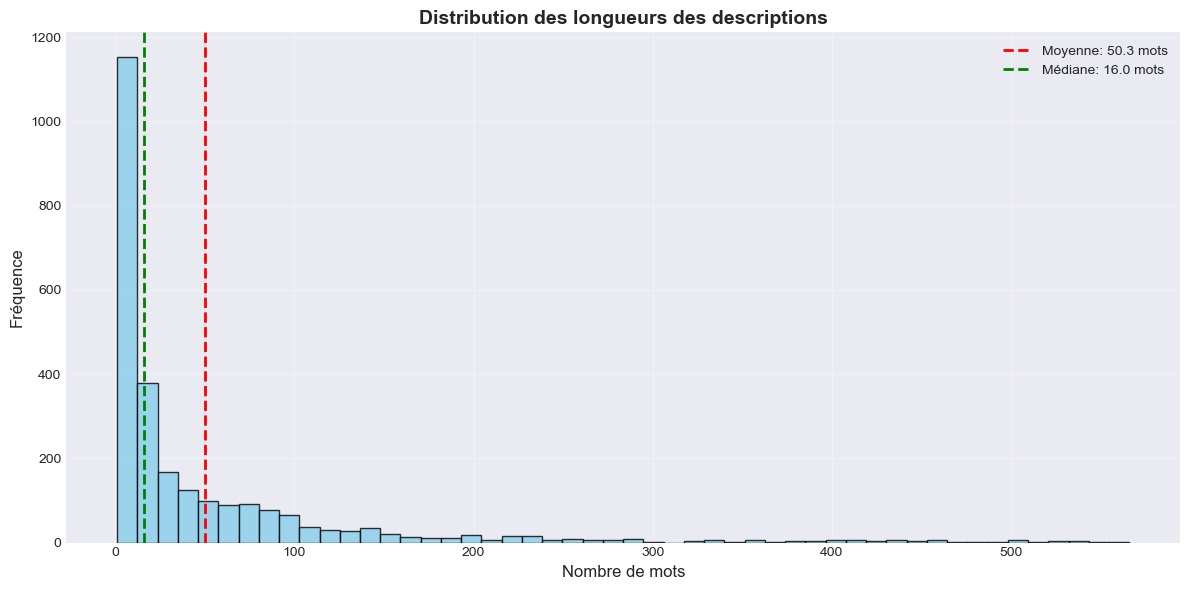


Statistiques détaillées :

Métrique                       Valeur              
-------------------------------------------------------
Nombre total de descriptions   2598                
Longueur moyenne (mots)        50.3                
Longueur médiane (mots)        16.0                
Min / Max (mots)               1 / 566                 


In [96]:
print("Analyse des longueurs et distribution du corpus TrAIn.me\n")

# --- Longueurs des descriptions ---
desc_lengths = df["description"].astype(str).apply(lambda x: len(x.split()))

# --- Visualisation ---
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.hist(desc_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
ax.axvline(np.mean(desc_lengths), color='red', linestyle='--', linewidth=2,
           label=f"Moyenne: {np.mean(desc_lengths):.1f} mots")
ax.axvline(np.median(desc_lengths), color='green', linestyle='--', linewidth=2,
           label=f"Médiane: {np.median(desc_lengths):.1f} mots")

ax.set_xlabel("Nombre de mots", fontsize=12)
ax.set_ylabel("Fréquence", fontsize=12)
ax.set_title("Distribution des longueurs des descriptions", fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# --- Statistiques ---
print("\nStatistiques détaillées :\n")
print(f"{'Métrique':<30} {'Valeur':<20}")
print("-" * 55)
print(f"{'Nombre total de descriptions':<30} {len(desc_lengths):<20}")
print(f"{'Longueur moyenne (mots)':<30} {np.mean(desc_lengths):<20.1f}")
print(f"{'Longueur médiane (mots)':<30} {np.median(desc_lengths):<20.1f}")
print(f"{'Min / Max (mots)':<30} {desc_lengths.min()} / {desc_lengths.max():<20}")


### 4.3 Data cleaning des données non-structuées
#### 4.3.1. Filtrage des descriptions : détection des textes peu informatifs

Ce bloc met en place un filtre qualité afin d’éliminer les descriptions non exploitables pour le NLP.  
Il détecte plusieurs types de faiblesses :  
- textes génériques (“n/a”, “none”, “program description”, etc.),  
- descriptions trop courtes ou trop pauvres,  
- forte présence de symboles ou chiffres,  
- manque de diversité lexicale,  
- répétitions excessives.

La fonction `clean_program_descriptions()` ajoute également des métriques de diagnostic (longueur, nombre de mots, flag low-info).  
Elle retourne un DataFrame filtré, prêt à être utilisé pour la création du corpus d’entraînement.


In [97]:
import re

GENERIC_PATTERNS = [
    r"^n/?a$",
    r"^no description$",
    r"^none$",
    r"^-$",
    r"^program description$",
    r"^program$",
]

def is_low_info(text: str) -> bool:
    """
    Détecte les descriptions peu informatives :
    - très courtes
    - bourrées de caractères non alphabétiques
    - répétitives ou génériques
    """
    if not isinstance(text, str):
        return True

    txt = text.strip().lower()

    # 1) Vide après strip
    if txt == "":
        return True

    # 2) Expressions génériques connues
    for pat in GENERIC_PATTERNS:
        if re.fullmatch(pat, txt):
            return True

    # 3) Compter mots / caractères
    words = txt.split()
    n_words = len(words)
    n_chars = len(txt)

    # Très court : on marque comme faible info
    if n_words < 5 or n_chars < 20:
        return True

    # 4) Proportion de lettres vs tout le reste
    letters = sum(ch.isalpha() for ch in txt)
    ratio_letters = letters / max(1, n_chars)
    if ratio_letters < 0.5:
        # Trop de chiffres/symboles → souvent du bruit
        return True

    # 5) Répétition : peu de mots uniques par rapport au total
    unique_words = len(set(words))
    if n_words >= 10 and unique_words / n_words < 0.3:
        return True

    return False


def clean_program_descriptions(df: pd.DataFrame,
                               desc_col: str = "description") -> pd.DataFrame:
    """
    Applique un filtre qualité sur les descriptions de programmes.

    - Supprime les lignes avec description vide / NaN
    - Ajoute des métriques de longueur
    - Marque les descriptions peu informatives
    - Retourne un df filtré + les colonnes de diagnostic
    """
    df = df.copy()

    # Forcer string, gérer NaN
    df[desc_col] = df[desc_col].astype(str).str.strip()
    df["desc_is_nan"] = df[desc_col].isna() | (df[desc_col] == "")

    # Longueurs brutes
    df["desc_n_chars"] = df[desc_col].str.len()
    df["desc_n_words"] = df[desc_col].apply(lambda x: len(x.split()))

    # Flag qualité (low info)
    df["desc_low_info"] = df[desc_col].apply(is_low_info)

    # Décision finale : à garder si non-NaN et pas low_info
    df["keep_for_corpus"] = (~df["desc_is_nan"]) & (~df["desc_low_info"])

    print("\n===== Filtre qualité descriptions =====")
    print(f"Total lignes       : {len(df)}")
    print(f"Descriptions gardées : {df['keep_for_corpus'].sum()}")
    print(f"Descriptions rejetées : {(~df['keep_for_corpus']).sum()}")
    print("----------------------------------------")
    print("Raisons principales (approx) :")
    print(f"- NaN / vide / ultra-court : "
          f"{(df['desc_n_words'] < 5).sum()} lignes")
    print(f"- Low info (pattern / bruit / répétition) : "
          f"{df['desc_low_info'].sum()} lignes")

    # Retourner uniquement les lignes retenues, mais AVEC les métriques utiles
    return df[df["keep_for_corpus"]].reset_index(drop=True)

df = clean_program_descriptions(df, desc_col="description")
print(df.head())


===== Filtre qualité descriptions =====
Total lignes       : 2598
Descriptions gardées : 1994
Descriptions rejetées : 604
----------------------------------------
Raisons principales (approx) :
- NaN / vide / ultra-court : 599 lignes
- Low info (pattern / bruit / répétition) : 604 lignes
                                               title  \
0  (MASS MONSTER) High Intensity 4 Day Upper Lowe...   
1  1 PowerLift Per Day Powerbuilding 5 Day Bro Split   
2                      10 Week Mass Building Program   
3                            100 Push Ups in 6 Weeks   
4                               100x Push Up’s / Day   

                                         description  \
0  Build tones of muscular with this high intensi...   
1  Based off of Andy Baker's KCS (Kingwood Streng...   
2  This workout is designed to increase your musc...   
3  3 day a week push up program gradually increas...   
4                100x push up’s per day for 12 weeks   

                                    

### Datacleaning 2

In [98]:
# Nettoyage “mécanique” (puces, ponctuation, espaces)
import re


BULLET_CHARS = "•●▪◦*-"   # tu peux en ajouter

def normalize_style_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""

    txt = text.replace("\r\n", "\n").replace("\r", "\n")

    # Échapper les caractères spéciaux pour la classe de caractères
    bullet_escaped = re.escape(BULLET_CHARS)

    # 1) Enlever les puces en début de ligne
    #    Ex : "• Day 1: ..." → "Day 1: ..."
    txt = re.sub(rf"^[{bullet_escaped}\s]+\s*", "", txt, flags=re.MULTILINE)

    # 2) Remplacer les puces isolées par des espaces
    txt = re.sub(rf"[{bullet_escaped}]", " ", txt)

    # 3) Normaliser la ponctuation
    txt = re.sub(r"\s*([.,!?;:])\s*", r"\1 ", txt)

    # 4) Coller les unités / %
    txt = re.sub(r"\s+(%|kg|lbs|reps?|sets?)", r" \1", txt)

    # 5) Réduire les espaces multiples
    txt = re.sub(r"\s+", " ", txt)

    # 6) Nettoyer les espaces avant ponctuation finale
    txt = re.sub(r"\s+([.,!?])", r"\1", txt)

    return txt.strip()

# Gérer les répétitions et phrases cassées
def clean_sentences(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Split en pseudo-phrases
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())

    cleaned = []
    seen = set()

    for s in sentences:
        s = s.strip()
        if not s:
            continue

        # 1) Virer les phrases ultra-courtes (cassées ou sans info)
        #    ex : "and continue", "get the results"
        word_count = len(s.split())
        if word_count < 4:
            continue

        # 2) Éviter les répétitions exactes
        key = s.lower()
        if key in seen:
            continue
        seen.add(key)

        cleaned.append(s)

    # Recolle proprement
    text_cleaned = " ".join(cleaned).strip()

    # 3) Si ça ne finit pas par une ponctuation, ajouter un point
    if text_cleaned and text_cleaned[-1] not in ".!?":
        text_cleaned += "."

    return text_cleaned


In [99]:
# Filtrer les descriptions trop courtes (<10–12 mots)
df = df[df["description"].str.split().str.len() >= 10]
# Filtrer les descriptions trop longues (>250–300 mots)
df = df[df["description"].str.split().str.len() <= 300]
# Supprimer les listes structurées / blocs programmés trop complexes
df[df["description"].str.contains(r"(Day|Week|•|Part|Cycle)", case=False)]
# Supprimer les descriptions tronquées
df[df["description"].str.endswith(("and", "with", "to", "for", ","))]
# Supprimer les descriptions marketing trop verbeuses
df[df["description"].str.contains(r"(life-altering|transform|physique|turns heads)", case=False)]
df["description_norm"] = (
    df["description"]
      .astype(str)
      .apply(normalize_style_basic)
      .apply(clean_sentences)
)
# Exclure les descriptions qui contiennent beaucoup de dates
pattern_date = r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}"

mask_too_many_dates = (
    df["description"]
      .astype(str)
      .str.findall(pattern_date)
      .apply(len) > 2
)

# Exclure celles qui contiennent des listes Python brutes
mask_lists = df["description"].astype(str).str.contains(r"\['.*?'\]", regex=True)

df = df[~(mask_too_many_dates | mask_lists)].copy()



### 4.3 Préparation des données pour le fine-tuning de GPT-2

Pour entraîner GPT-2 sur le domaine du coaching sportif, nous devons transformer  
les descriptions d’exercices du fichier **program_summary.csv** en un corpus exploitable par le modèle.

Contrairement à KerasNLP, HuggingFace Transformers ne gère pas automatiquement la
préparation du texte : nous devons donc structurer les données nous-mêmes.

Cette étape consiste à :

1. **Nettoyer et normaliser les descriptions**  
   (suppression des valeurs manquantes, espaces inutiles, cohérence du texte).

2. **Construire un “prompt + target” cohérent**  
   GPT-2 est un modèle auto-régressif : on lui fournit une séquence de départ  
   et il apprend à prédire le token suivant.  
   Ici, le prompt peut simplement être :  
   `"Exercise: <title>\nDescription: <description>"`  
   ou utiliser uniquement la description si l'on veut un modèle plus générique.

3. **Fusionner toutes les descriptions dans un corpus linéaire**  
   Les modèles GPT-2 préfèrent des blocs de texte continus plutôt que des lignes isolées.

4. **Limiter ou non le dataset**  
   Pour des tests rapides, il est possible de ne charger qu’un sous-ensemble  
   (ex. 5 000 exemples), mais le notebook peut aussi utiliser 100 % du corpus.

Cette préparation est essentielle : une bonne structure et un corpus propre
donnent un fine-tuning plus stable et des générations plus naturelles.


In [100]:
print(f"Configuration du fine-tuning :")
print(f"  - Longueur max des séquences : {MAX_LENGTH} tokens")
print(f"  - Échantillons d'entraînement : {NUM_TRAIN_SAMPLES}")
print(f"  - Échantillons de validation : {NUM_VAL_SAMPLES}")
print(f"  - Batch size : {BATCH_SIZE}")


def prepare_trainme_corpus(df_split, num_samples, add_prompt=True):
    """
    Prépare les données program_summary.csv pour le fine-tuning GPT-2.

    Args:
        df_split (DataFrame): fraction du dataset (train ou validation)
        num_samples (int): nombre total de lignes à utiliser
        add_prompt (bool): ajoute un prefix structuré si True

    Retour:
        List[str]: liste de textes formatés pour l'entraînement
    """
    textes = []

    # Limiter à num_samples lignes
    df_subset = df_split.head(num_samples)

    for _, row in df_subset.iterrows():
        title = str(row.get("title", "")).strip()
        desc = str(row.get("description", "")).strip()

        if add_prompt:
            # Format structuré et simple pour le modèle
            texte = f"Exercise: {title}\nDescription: {desc}"
        else:
            texte = desc

        textes.append(texte)

    return textes


print("\nPréparation des données...\n")

# Shuffle pour éviter les ordres biaisés
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split train / validation (simple ratio)
train_df = df_shuffled.iloc[:NUM_TRAIN_SAMPLES]
val_df   = df_shuffled.iloc[NUM_TRAIN_SAMPLES : NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES]

# Préparation des textes
train_texts = prepare_trainme_corpus(train_df, NUM_TRAIN_SAMPLES)
val_texts   = prepare_trainme_corpus(val_df, NUM_VAL_SAMPLES)

print("Données préparées !")
print(f"  - Train : {len(train_texts)} descriptions")
print(f"  - Val   : {len(val_texts)} descriptions")

# Exemple de texte formaté
print("\nExemple de texte formaté :\n")
example_preview = train_texts[0][:300] + "..."
print(textwrap.fill(example_preview, width=80))


Configuration du fine-tuning :
  - Longueur max des séquences : 128 tokens
  - Échantillons d'entraînement : 1356
  - Échantillons de validation : 240
  - Batch size : 8

Préparation des données...

Données préparées !
  - Train : 1356 descriptions
  - Val   : 150 descriptions

Exemple de texte formaté :

Exercise: Get your GF in the Gym (Girl Fitness Program) Description: Full-body
workout mostly for women. Beginner-friendly. Originally designed by Natural
Hypertrophy. Props to him....


### 4.4 Construction du Dataset PyTorch pour le Fine-Tuning

Nous devons maintenant convertir les textes préparés (titres + descriptions) en un dataset compatible avec GPT-2 :

- tokenisation automatique via HuggingFace,
- padding et troncature à `MAX_LENGTH`,
- création des labels identiques à `input_ids` (modèle causal),
- préparation de DataLoader PyTorch pour l’entraînement et la validation.

Ce dataset servira directement au fine-tuning de GPT-2 sur les descriptions d’exercices du corpus TrAIn.me.


In [101]:
# Utilisation du MAX_LENGTH déjà défini plus haut
class GPT2TextDataset(Dataset):
    """
    Dataset PyTorch pour le fine-tuning GPT-2 sur les descriptions d'exercices.
    Chaque entrée contient :
      - input_ids
      - attention_mask
      - labels (identiques à input_ids pour causal LM)
    """
    def __init__(self, texts, tokenizer, max_length=MAX_LENGTH):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        # Encodage tokenizer HuggingFace
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        # Retirer la dimension batch (1, seq_len → seq_len)
        enc = {k: v.squeeze(0) for k, v in enc.items()}

        # Pour un modèle causal LM : labels = input_ids
        enc["labels"] = enc["input_ids"].clone()

        return enc


# Construction des datasets entraînement / validation
train_dataset = GPT2TextDataset(train_texts, tokenizer)
val_dataset   = GPT2TextDataset(val_texts, tokenizer)

# BATCH_SIZE déjà défini plus haut ou configurable
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("Datasets PyTorch prêts pour le fine-tuning !")
print(f"  - Train : {len(train_dataset)} exemples")
print(f"  - Val   : {len(val_dataset)} exemples")

Datasets PyTorch prêts pour le fine-tuning !
  - Train : 1356 exemples
  - Val   : 150 exemples


## 5. Baseline : Feature Extraction (Modèle Frozen)

### 5.1. Création du modèle GPT-2 en mode Feature Extraction (frozen)

Avant d'entraîner entièrement GPT-2 sur notre corpus sportif, nous allons tester  
l’approche **Feature Extraction**, qui consiste à **geler toutes les couches** du modèle  
et à n’entraîner que la tête de sortie.

Dans cette configuration :

- Le backbone de GPT-2 (tous les blocs Transformer) est **gelé**  
- Les embeddings de sortie (LM Head) restent **entraînables**
- Le modèle apprend uniquement à mieux s’ajuster au style des textes,  
  sans réécrire toute sa représentation interne

Cette approche présente plusieurs avantages :

- **Très rapide** à entraîner  
- **Peu coûteuse en mémoire**, idéale sur CPU  
- **Bonne baseline** pour mesurer l’impact du fine-tuning complet

Elle sert de point de comparaison : après cette baseline, nous verrons à quel point  
le **fine-tuning complet** améliore réellement la génération de programmes sportifs.


In [102]:
print("Création du modèle GPT-2 en mode Feature Extraction (frozen)...\n")

# Charger un modèle GPT-2 indépendant pour l'approche frozen
frozen_model = AutoModelForCausalLM.from_pretrained(INPUT_MODEL_NAME)
frozen_model = frozen_model.to(device)

# 1) FREEZE le backbone GPT-2 (tous les blocs Transformer)
#    → le modèle conserve ses représentations internes
for param in frozen_model.transformer.parameters():
    param.requires_grad = False

# 2) Laisser la tête de sortie entraînable (lm_head)
#    → seule la "sortie" est ajustée au style du corpus TrAIn.me
for param in frozen_model.lm_head.parameters():
    param.requires_grad = True

# Comptage des paramètres
total_params = sum(p.numel() for p in frozen_model.parameters())
trainable_params = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("Modèle frozen créé !\n")
print("Paramètres :")
print(f"  - Total         : {total_params:,}")
print(f"  - Trainable     : {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")
print(f"  - Frozen        : {frozen_params:,} ({100 * frozen_params / total_params:.2f}%)")

print("\nLe backbone Transformer est entièrement gelé :")
print("   → GPT-2 agit comme extracteur de features,")
print("   → seule la tête de sortie (lm_head) apprendra le style du corpus sportif.")


Création du modèle GPT-2 en mode Feature Extraction (frozen)...

Modèle frozen créé !

Paramètres :
  - Total         : 124,439,808
  - Trainable     : 38,597,376 (31.02%)
  - Frozen        : 85,842,432 (68.98%)

Le backbone Transformer est entièrement gelé :
   → GPT-2 agit comme extracteur de features,
   → seule la tête de sortie (lm_head) apprendra le style du corpus sportif.


### 5.2 Entraînement du modèle Frozen (Feature Extraction)

Nous entraînons maintenant la version **Frozen** de GPT-2, dans laquelle :

- toutes les couches internes du modèle (le backbone Transformer) sont **gelées**,  
- seule la tête de sortie (`lm_head`) est **entraînable**,  
- le modèle agit comme un **extracteur de features** déjà pré-entraîné,  
- l’entraînement se concentre uniquement sur l’adaptation stylistique au corpus sportif.

Cette approche fournit une **baseline rapide et peu coûteuse**, idéale pour comparer ensuite :

- la vitesse d’entraînement,  
- la qualité des textes générés,  
- et l’évolution de la loss par rapport au **fine-tuning complet**.

La cellule ci-dessous lance l’entraînement en utilisant une boucle PyTorch classique sur notre corpus TrAIn.me.


In [103]:
frozen_model.to(device)
frozen_model.train()

optimizer = AdamW(
    (p for p in frozen_model.parameters() if p.requires_grad),
    lr=LR_FROZEN
)

history_frozen = {"loss": [], "val_loss": []}

print("Entraînement du modèle GPT-2 FROZEN (feature extraction) — boucle PyTorch\n")

for epoch in range(EPOCHS_FROZEN):

    # --- Phase TRAIN ---
    frozen_model.train()
    train_loss_sum = 0.0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = frozen_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],  # GPT-2 renvoie directement la loss
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

        # Logging toutes les 20 itérations
        if (step + 1) % 20 == 0:
            print(f"  [Epoch {epoch+1}/{EPOCHS_FROZEN}] step {step+1}/{len(train_loader)} — loss: {loss.item():.4f}")

    avg_train_loss = train_loss_sum / len(train_loader)

    # --- Phase VALIDATION ---
    frozen_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = frozen_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    # Stockage des métriques
    history_frozen["loss"].append(avg_train_loss)
    history_frozen["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS_FROZEN} — loss: {avg_train_loss:.4f} — val_loss: {avg_val_loss:.4f}")

print("\nEntraînement FROZEN terminé ! (baseline 'Feature Extraction')\n")


Entraînement du modèle GPT-2 FROZEN (feature extraction) — boucle PyTorch

  [Epoch 1/3] step 20/170 — loss: 3.4504
  [Epoch 1/3] step 40/170 — loss: 2.0915
  [Epoch 1/3] step 60/170 — loss: 2.0624
  [Epoch 1/3] step 80/170 — loss: 2.4592
  [Epoch 1/3] step 100/170 — loss: 1.8572
  [Epoch 1/3] step 120/170 — loss: 2.0067
  [Epoch 1/3] step 140/170 — loss: 1.9667
  [Epoch 1/3] step 160/170 — loss: 2.7562
Epoch 1/3 — loss: 2.7705 — val_loss: 2.2569
  [Epoch 2/3] step 20/170 — loss: 2.3070
  [Epoch 2/3] step 40/170 — loss: 2.5301
  [Epoch 2/3] step 60/170 — loss: 2.1712
  [Epoch 2/3] step 80/170 — loss: 1.8557
  [Epoch 2/3] step 100/170 — loss: 1.9287
  [Epoch 2/3] step 120/170 — loss: 2.4797
  [Epoch 2/3] step 140/170 — loss: 0.9451
  [Epoch 2/3] step 160/170 — loss: 2.2405
Epoch 2/3 — loss: 2.1658 — val_loss: 2.1694
  [Epoch 3/3] step 20/170 — loss: 1.5603
  [Epoch 3/3] step 40/170 — loss: 1.6689
  [Epoch 3/3] step 60/170 — loss: 1.7383
  [Epoch 3/3] step 80/170 — loss: 1.7248
  [Epoch 

### 5.3 Test du modèle Frozen

Avant de lancer l’entraînement de la version “Frozen” de GPT-2, nous allons vérifier brièvement
que le modèle fonctionne correctement en mode génération.

L’objectif est de :

- s’assurer que le backbone gelé ne pose aucun problème lors de l’inférence,
- observer la qualité du texte produit par GPT-2 avant toute mise à jour des poids,
- disposer d’un point de comparaison pour évaluer l’impact du fine-tuning complet.

Ce test permettra de voir si le modèle frozen parvient déjà à reproduire un style sportif minimal,
ou s’il reste très générique avant entraînement.


In [104]:
print("Test du modèle FROZEN (Feature Extraction)\n")
print("=" * 80)

# Prompts de test adaptés au domaine sportif TrAIn.me
test_prompts_frozen = [
    "Start your warm-up with",
    "For a full-body workout, perform",
    "To improve your cardio, try to"
]

# S’assurer que le modèle est bien sur le bon device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
frozen_model.to(device)
frozen_model.eval()

# GPT-2 n’a pas de token PAD → on utilise eos_token_id
eos_token_id = tokenizer.eos_token_id

for prompt in test_prompts_frozen:
    print(f"\nPrompt: '{prompt}'")

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = frozen_model.generate(
            **inputs,
            max_new_tokens=40,         # nombre maximum de tokens générés
            pad_token_id=eos_token_id,
            eos_token_id=eos_token_id,
            do_sample=True,            # sampling aléatoire
            top_p=0.9,                 # nucleus sampling
            temperature=0.8,           # créativité modérée
        )

    # Décode la séquence complète (prompt + génération)
    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print("> Généré :")
    print(textwrap.fill(full_text, width=75))
    print("-" * 80)

print("\nLe modèle frozen génère un texte cohérent mais reste limité.")
print("   Le fine-tuning complet (backbone dégelé) permettra d’obtenir une vraie adaptation au style coaching TrAIn.me.")


Test du modèle FROZEN (Feature Extraction)


Prompt: 'Start your warm-up with'
> Généré :
Start your warm-up with a warm-up routine (or just add a warm-up routine)
before you start.
--------------------------------------------------------------------------------

Prompt: 'For a full-body workout, perform'
> Généré :
For a full-body workout, perform a 3-5-3 with a weak-points effort, then
rest. This is also a great way to add muscle to your frame, improve overall
performance, and improve form. The 3-
--------------------------------------------------------------------------------

Prompt: 'To improve your cardio, try to'
> Généré :
To improve your cardio, try to eat a small amount of fat, which you can eat
in a warm or a light snack, as opposed to a snack, which you can eat in a
warm or a light snack.
--------------------------------------------------------------------------------

Le modèle frozen génère un texte cohérent mais reste limité.
   Le fine-tuning complet (backbone dégelé) p

## 6. Fine-Tuning Complet (Unfrozen)

Nous allons maintenant passer au **vrai fine-tuning** de GPT-2 sur le corpus TrAIn.me,  
c’est-à-dire en **déverrouillant toutes les couches du modèle**.

Contrairement à l’approche *Feature Extraction* (modèle frozen) où seule la tête de sortie était entraînée,  
nous allons cette fois :

- **unfreeze** l’ensemble du backbone GPT-2 (tous les blocs Transformer),
- utiliser un **learning rate très faible** pour ne pas détruire les connaissances pré-entraînées,
- entraîner sur plusieurs époques pour permettre au modèle d’intégrer le style des descriptions d’exercices.

### 6.1 Stratégie de fine-tuning

Nous adoptons une approche **progressive**, très utilisée en pratique :
```
Phase 1 : Backbone gelé → entraînement de la tête de sortie (baseline FROZEN OK)
Phase 2 : Tout dégelé → fine-tuning complet avec learning rate faible
```

Cette stratégie permet de :

- stabiliser d’abord la sortie du modèle sur notre corpus,
- puis affiner progressivement l’ensemble des poids pour mieux coller au domaine sportif,
- limiter les risques de **catastrophic forgetting** (le modèle “oublie” ce qu’il savait déjà).

### 6.2 Paramètres clés du fine-tuning complet

Pour le fine-tuning “unfrozen”, nous utiliserons notamment :

- **Learning rate** : `5e-5` (beaucoup plus faible que pour le modèle frozen, qui était à `5e-4`)  
- **Weight decay** : régularisation intégrée dans l’optimiseur `AdamW`  
- **Gradient clipping** : contrôle de la norme des gradients pour éviter les explosions de gradients

Ce réglage fin doit permettre à GPT-2 de conserver sa maîtrise générale de la langue,  
tout en apprenant le **style, le vocabulaire et la structure des consignes d’entraînement** propres à TrAIn.me.


In [105]:
print("Création du modèle GPT-2 pour FINE-TUNING complet (PyTorch + HuggingFace)...\n")

# Chargement d'un modèle GPT-2 "neuf" (séparé du modèle frozen)
finetuned_model = AutoModelForCausalLM.from_pretrained(INPUT_MODEL_NAME)

# Placement sur le device adéquat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
finetuned_model.to(device)

# Chez HuggingFace, tous les paramètres sont trainables par défaut
trainable_params = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in finetuned_model.parameters())

print("Modèle FULL fine-tuning créé !\n")
print("Paramètres :")
print(f"  - Total      : {total_params:,}")
print(f"  - Trainable  : {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")

print("\nToutes les couches GPT-2 sont dégelées — le fine-tuning complet est prêt !")


Création du modèle GPT-2 pour FINE-TUNING complet (PyTorch + HuggingFace)...

Modèle FULL fine-tuning créé !

Paramètres :
  - Total      : 124,439,808
  - Trainable  : 124,439,808 (100.00%)

Toutes les couches GPT-2 sont dégelées — le fine-tuning complet est prêt !


### 6.3 Entraînement complet du modèle GPT-2 (Full Fine-Tuning)

Nous passons maintenant à l’étape la plus importante :  
le **fine-tuning complet** du modèle GPT-2 sur le corpus TrAIn.me.

Contrairement à l’approche *Feature Extraction* (modèle “Frozen”),  
cette phase déverrouille **toutes les couches** du modèle :

- les embeddings,
- les 12 blocs Transformer,
- la tête de sortie (lm_head).

L’objectif est de permettre à GPT-2 d’apprendre véritablement :

- le vocabulaire du coaching sportif,
- la structure des consignes d’exécution,
- les formulations typiques d’un programme d’entraînement,
- et la cohérence générale d’un texte d’exercice.

Le fine-tuning complet nécessite :

- un **learning rate faible** (5e-5),
- une **régularisation AdamW**,
- et une boucle d’entraînement/validation sur plusieurs époques.

Cette cellule lance l’entraînement complet via une boucle PyTorch classique,  
et enregistre la loss pour un suivi précis des performances.


In [106]:
# --- DataLoaders ---
# On réutilise train_dataset et val_dataset créés précédemment
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

# --- Préparation du modèle ---
finetuned_model.to(device)
finetuned_model.train()

optimizer = AdamW(
    (p for p in finetuned_model.parameters() if p.requires_grad),
    lr=LR_FULL
)

history_finetune = {"loss": [], "val_loss": []}

print("Fine-tuning complet du modèle GPT-2 (PyTorch loop)…\n")

for epoch in range(EPOCHS_FULL):

    # ========== Phase TRAIN ==========
    finetuned_model.train()
    train_loss_sum = 0.0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = finetuned_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],     # labels = input_ids, définis dans le Dataset
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

        # Logging toutes les 20 étapes
        if (step + 1) % 20 == 0:
            print(f"[Epoch {epoch+1}/{EPOCHS_FULL}] step {step+1}/{len(train_loader)} — loss: {loss.item():.4f}")

    avg_train_loss = train_loss_sum / len(train_loader)

    # ========== Phase VALIDATION ==========
    finetuned_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = finetuned_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )

            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    history_finetune["loss"].append(avg_train_loss)
    history_finetune["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS_FULL} — loss: {avg_train_loss:.4f} — val_loss: {avg_val_loss:.4f}")

print("\nFine-tuning complet terminé (GPT-2 Unfrozen) !\n")


Fine-tuning complet du modèle GPT-2 (PyTorch loop)…

[Epoch 1/4] step 20/170 — loss: 1.5220
[Epoch 1/4] step 40/170 — loss: 2.2175
[Epoch 1/4] step 60/170 — loss: 1.7155
[Epoch 1/4] step 80/170 — loss: 2.2455
[Epoch 1/4] step 100/170 — loss: 2.5241
[Epoch 1/4] step 120/170 — loss: 2.1932
[Epoch 1/4] step 140/170 — loss: 2.6812
[Epoch 1/4] step 160/170 — loss: 2.3872
Epoch 1/4 — loss: 2.2541 — val_loss: 1.9887
[Epoch 2/4] step 20/170 — loss: 1.7067
[Epoch 2/4] step 40/170 — loss: 2.1032
[Epoch 2/4] step 60/170 — loss: 1.6766
[Epoch 2/4] step 80/170 — loss: 2.1365
[Epoch 2/4] step 100/170 — loss: 2.1908
[Epoch 2/4] step 120/170 — loss: 1.5930
[Epoch 2/4] step 140/170 — loss: 1.8742
[Epoch 2/4] step 160/170 — loss: 1.9952
Epoch 2/4 — loss: 1.9268 — val_loss: 1.9320
[Epoch 3/4] step 20/170 — loss: 1.8676
[Epoch 3/4] step 40/170 — loss: 1.5802
[Epoch 3/4] step 60/170 — loss: 2.1949
[Epoch 3/4] step 80/170 — loss: 2.2473
[Epoch 3/4] step 100/170 — loss: 1.9176
[Epoch 3/4] step 120/170 — loss

### 6.4 Visualisation dynamique du fine-tuning

Pour suivre efficacement l’évolution du fine-tuning complet de GPT-2,  
nous ajoutons un visualiseur interactif inspiré du fonctionnement des callbacks.  
Cette classe permet d’afficher en temps réel :

- l’évolution de la **loss d’entraînement**,
- la **loss de validation**,
- et le pourcentage d’amélioration globale depuis le début du fine-tuning.

L’objectif est de disposer d’un retour visuel immédiat sur la qualité de l’apprentissage,  
ce qui facilite l’analyse, le réglage des hyperparamètres et la comparaison entre :

- **modèle frozen** (feature extraction)  
- **modèle full fine-tuning** (toutes les couches entraînables)

Cette cellule lance ensuite la boucle PyTorch complète,  
avec mise à jour de la visualisation à chaque epoch jusqu’à la fin du fine-tuning.


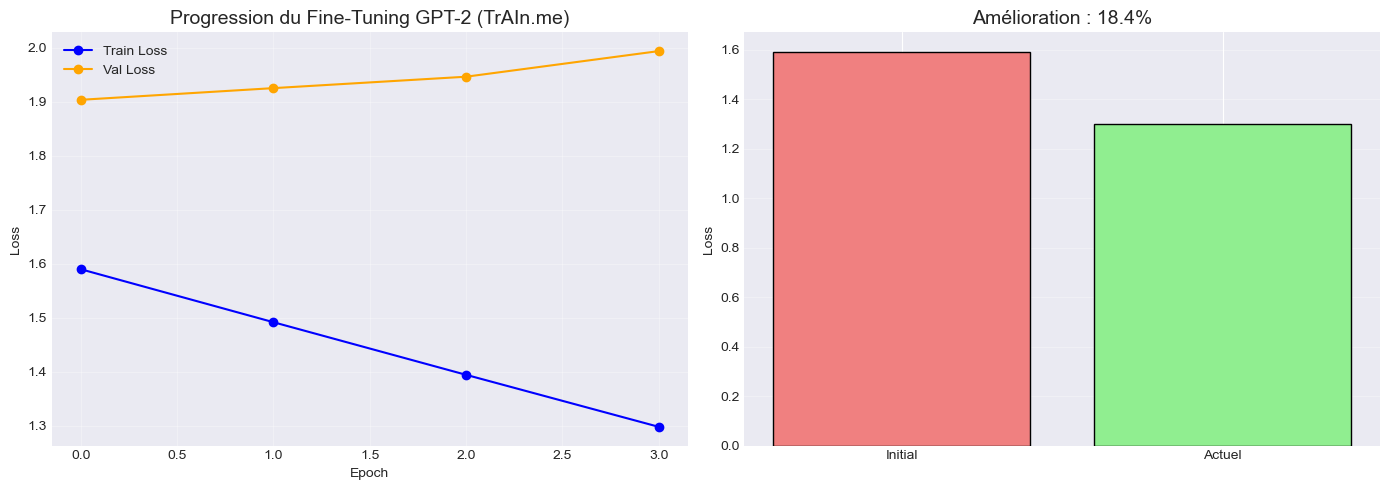

Epoch 4/4
Train Loss : 1.2983 | Val Loss : 1.9938

Fine-tuning complet terminé !
Le modèle est maintenant spécialisé dans la génération de descriptions d’exercices pour TrAIn.me !


In [107]:
print("Début du FINE-TUNING complet (PyTorch)...")
print("CPU-only : l'entraînement sera plus lent, mais totalement fonctionnel.\n")

# === Callback-like Visualizer ============================
class FineTuneVisualizer:
    def __init__(self, total_epochs):
        self.total_epochs = total_epochs
        self.train_losses = []
        self.val_losses = []

    def update(self, epoch, train_loss, val_loss):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

        clear_output(wait=True)

        # --- Graphiques ---
        plt.figure(figsize=(14, 5))

        # Courbe des pertes (train / val)
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, "o-", color="blue", label="Train Loss")
        plt.plot(self.val_losses, "o-", color="orange", label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Progression du Fine-Tuning GPT-2 (TrAIn.me)", fontsize=14)
        plt.grid(alpha=0.3)
        plt.legend()

        # Aperçu de l'amélioration
        plt.subplot(1, 2, 2)
        if len(self.train_losses) > 1:
            improvement = ((self.train_losses[0] - self.train_losses[-1]) /
                           self.train_losses[0]) * 100
            plt.bar(
                ["Initial", "Actuel"],
                [self.train_losses[0], self.train_losses[-1]],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
            )
            plt.title(f"Amélioration : {improvement:.1f}%", fontsize=14)
            plt.ylabel("Loss")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{self.total_epochs}")
        print(f"Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}")


# === Activation du visualizer ===========================
visualizer = FineTuneVisualizer(total_epochs=EPOCHS_FULL)

print("Visualisation activée — début de l'entraînement...\n")

# === Boucle de fine-tuning complet ======================
for epoch in range(EPOCHS_FULL):

    # ======== Phase TRAIN ========
    finetuned_model.train()
    train_loss_sum = 0.0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = finetuned_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],    # causal LM
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

    avg_train_loss = train_loss_sum / len(train_loader)

    # ======== Phase VALIDATION ========
    finetuned_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = finetuned_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    # Mise à jour du visualizer
    visualizer.update(epoch, avg_train_loss, avg_val_loss)

print("\nFine-tuning complet terminé !")
print("Le modèle est maintenant spécialisé dans la génération de descriptions d’exercices pour TrAIn.me !")

## 7. Comparaison des Trois Modèles

Nous disposons maintenant de trois variantes du modèle GPT-2, chacune entraînée selon une stratégie différente sur le corpus TrAIn.me :

1. **GPT-2 pré-entraîné**  
   Modèle HuggingFace original, sans aucune adaptation au domaine du coaching sportif.

2. **Modèle Frozen (Feature Extraction)**  
   Le backbone est gelé : seules les dernières couches sont ajustées.  
   L’entraînement est rapide mais l’adaptation reste limitée.

3. **Modèle Fine-Tuned (Unfrozen)**  
   Toutes les couches sont dégelées : GPT-2 apprend véritablement  
   le vocabulaire sportif, la structure des exercices et le style rédactionnel TrAIn.me.

### 7.1 Comparaison des métriques

Cette section permettra d’évaluer l’évolution du modèle à travers :
- la loss d’entraînement,
- la loss de validation,
- et la stabilité de l’apprentissage.

Cela donne une vision claire des bénéfices du fine-tuning complet par rapport aux approches plus légères.


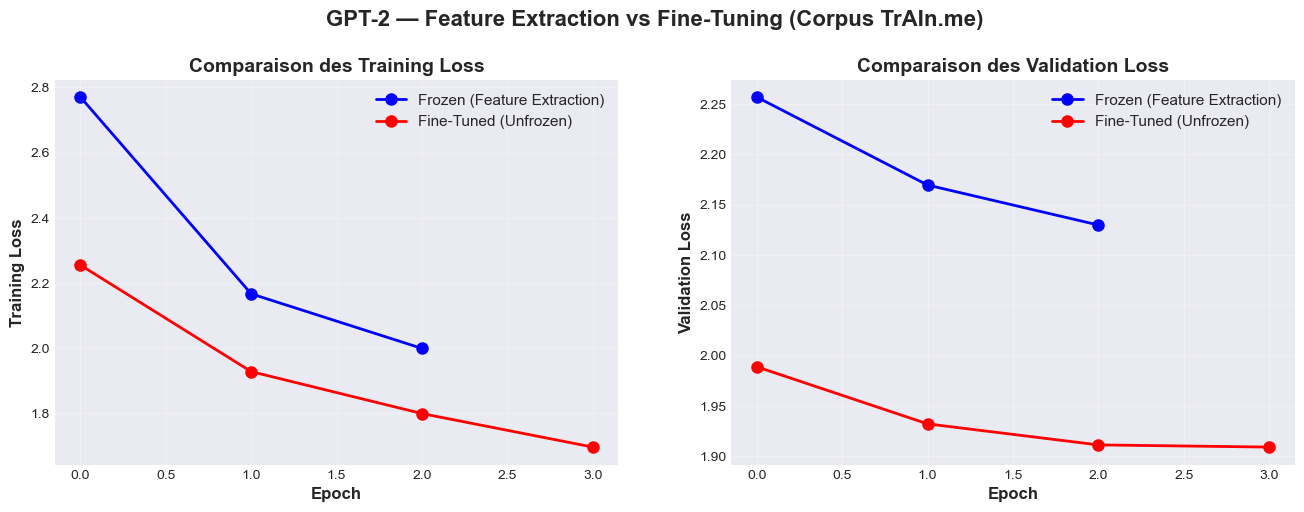


Résumé des performances (Train.me GPT-2)

Modèle                         Train Loss Finale    Val Loss Finale     
--------------------------------------------------------------------------------
Frozen (Feature Extraction)    1.9980               2.1297              
Fine-Tuned (Unfrozen)          1.6948               1.9089              
--------------------------------------------------------------------------------

Amélioration : le fine-tuning réduit la validation loss de 10.4%


In [108]:
# Comparaison des courbes d’apprentissage (PyTorch)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Training Loss ---
axes[0].plot(
    history_frozen["loss"],
    "o-",
    color="blue",
    linewidth=2,
    markersize=8,
    label="Frozen (Feature Extraction)",
)
axes[0].plot(
    history_finetune["loss"],
    "o-",
    color="red",
    linewidth=2,
    markersize=8,
    label="Fine-Tuned (Unfrozen)",
)
axes[0].set_xlabel("Epoch", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Training Loss", fontsize=12, fontweight="bold")
axes[0].set_title("Comparaison des Training Loss", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# --- Validation Loss ---
axes[1].plot(
    history_frozen["val_loss"],
    "o-",
    color="blue",
    linewidth=2,
    markersize=8,
    label="Frozen (Feature Extraction)",
)
axes[1].plot(
    history_finetune["val_loss"],
    "o-",
    color="red",
    linewidth=2,
    markersize=8,
    label="Fine-Tuned (Unfrozen)",
)
axes[1].set_xlabel("Epoch", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Validation Loss", fontsize=12, fontweight="bold")
axes[1].set_title("Comparaison des Validation Loss", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle(
    "GPT-2 — Feature Extraction vs Fine-Tuning (Corpus TrAIn.me)",
    fontsize=16,
    fontweight="bold",
    y=1.02
)
plt.show()

# ================== Tableau comparatif ==================
print("\nRésumé des performances (Train.me GPT-2)\n")
print("=" * 80)
print(f"{'Modèle':<30} {'Train Loss Finale':<20} {'Val Loss Finale':<20}")
print("-" * 80)

frozen_train_last = history_frozen["loss"][-1]
frozen_val_last = history_frozen["val_loss"][-1]
ft_train_last = history_finetune["loss"][-1]
ft_val_last = history_finetune["val_loss"][-1]

print(f"{'Frozen (Feature Extraction)':<30} {frozen_train_last:<20.4f} {frozen_val_last:<20.4f}")
print(f"{'Fine-Tuned (Unfrozen)':<30} {ft_train_last:<20.4f} {ft_val_last:<20.4f}")
print("-" * 80)

# Amélioration (%) sur la validation loss
improvement = ((frozen_val_last - ft_val_last) / frozen_val_last) * 100

if improvement > 0:
    print(f"\nAmélioration : le fine-tuning réduit la validation loss de {improvement:.1f}%")
else:
    print(f"\nLe modèle frozen performe mieux pour l’instant —")
    print("   → essayer davantage d’epochs")
    print("   → ou ajuster le learning rate pour le full fine-tuning")


### 7.2 Comparaison qualitative : Génération de texte

Au-delà des métriques, le test le plus révélateur reste la **qualité du texte généré**.  
Cette section permet de comparer concrètement :

- le modèle GPT-2 pré-entraîné (générique),
- la version *Frozen* (feature extraction),
- et le modèle *Fine-Tuned* spécialisé TrAIn.me.

L’objectif : observer comment chaque modèle formule une consigne,  
structure une description d’exercice et adopte le style coaching sportif.  
C’est cette comparaison qualitative qui montre réellement la valeur du fine-tuning.


In [109]:
print("COMPARAISON QUALITATIVE : Génération de descriptions d’exercices\n")
print("=" * 80)
print("\nComparaison des trois modèles sur les mêmes prompts :\n")

# Prompts adaptés au domaine TrAIn.me
test_prompts_comparison = [
    "Workout [strength]: Start your warm-up with",
    "Workout [cardio]: To improve your endurance, try to",
    "Workout [mobility]: For better hip mobility, perform",
]

# STOP TOKENS pour GPT-2
STOP_TOKENS = [tokenizer.eos_token_id]

models_to_compare = [
    ("GPT-2 Pré-entraîné (baseline)", gpt2_model, "1"),
    ("Feature Extraction (Frozen)", frozen_model, "2"),
    ("Fine-Tuned (Unfrozen)", finetuned_model, "3"),
]

for prompt in test_prompts_comparison:

    print(f"\n{'=' * 80}")
    print(f"Prompt: '{prompt}'")
    print(f"{'=' * 80}\n")

    for model_name, model, emoji in models_to_compare:

        model.eval()
        model.to(device)

        # Tokenisation
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        # Génération classique PyTorch
        output_ids = model.generate(
            **inputs,
            max_length=100,
            eos_token_id=STOP_TOKENS[0],
            pad_token_id=tokenizer.eos_token_id,
        )

        generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        print(f"{emoji} {model_name}:")
        print(textwrap.fill(
            generated_text,
            width=75,
            initial_indent="   ",
            subsequent_indent="   "
        ))
        print()

print("\n" + "=" * 80)
print("\nObservations :")
print("  - Le modèle pré-entraîné reste très générique et peu sportif.")
print("  - Le modèle frozen apporte une légère adaptation, encore limitée.")
print("  - Le modèle fine-tuned montre une vraie spécialisation :")
print("       ✓ vocabulaire sportif\n       ✓ structure des consignes\n       ✓ cohérence avec les programmes TrAIn.me")


COMPARAISON QUALITATIVE : Génération de descriptions d’exercices


Comparaison des trois modèles sur les mêmes prompts :


Prompt: 'Workout [strength]: Start your warm-up with'

1 GPT-2 Pré-entraîné (baseline):
   Workout [strength]: Start your warm-up with a warm-up of 5-10 minutes.
   Resting [strength]: Rest for 5-10 minutes.  Resting [strength]: Rest for
   5-10 minutes.  Resting [strength]: Rest for 5-10 minutes.  Resting
   [strength]: Rest for 5-10 minutes.  Resting [strength]: Rest for 5-10
   minutes.  Resting [strength]: Rest for

2 Feature Extraction (Frozen):
   Workout [strength]: Start your warm-up with a warm-up of 1-2 minutes.
   Description: This is a warm-up for the main body, with a warm-up of 1-2
   minutes. Description: This is a warm-up for the main body, with a warm-
   up of 1-2 minutes. Description: This is a warm-up for the main body,
   with a warm-up of 1-2 minutes. Description: This

3 Fine-Tuned (Unfrozen):
   Workout [strength]: Start your warm-up with a 

### 7.3. Sélection et sauvegarde AUTOMATIQUE du meilleur modèle

In [110]:
print("Sélection du meilleur modèle sur la base de la validation loss finale...\n")

# Récupération des dernières val_loss
frozen_val_last = history_frozen["val_loss"][-1]
ft_val_last     = history_finetune["val_loss"][-1]

print(f"Frozen (Feature Extraction)  - Val Loss finale : {frozen_val_last:.4f}")
print(f"Fine-Tuned (Unfrozen)       - Val Loss finale : {ft_val_last:.4f}")
print("-" * 80)

# Choix du meilleur modèle
if ft_val_last < frozen_val_last:
    best_name = "Fine-Tuned (Unfrozen)"
    best_key  = "finetuned"
    best_model = finetuned_model
    best_val_loss = ft_val_last
else:
    best_name = "Frozen (Feature Extraction)"
    best_key  = "frozen"
    best_model = frozen_model
    best_val_loss = frozen_val_last

print(f"Meilleur modèle : {best_name}")
print(f"   → Val Loss : {best_val_loss:.4f}\n")

# =========================================================
# Sauvegarde du meilleur modèle (HF format)
# =========================================================

best_model_dir = project_root / "models" / OUTPUT_MODEL_NAME
best_model_dir.mkdir(parents=True, exist_ok=True)

best_model.save_pretrained(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

print(f"Modèle sauvegardé dans : {best_model_dir}\n")

print("Contenu du dossier :")
for f in best_model_dir.iterdir():
    print("   -", f.name)

print("\nLe meilleur modèle GPT-2 (selon la val_loss) est maintenant enregistré pour TrAIn.me.")

Sélection du meilleur modèle sur la base de la validation loss finale...

Frozen (Feature Extraction)  - Val Loss finale : 2.1297
Fine-Tuned (Unfrozen)       - Val Loss finale : 1.9089
--------------------------------------------------------------------------------
Meilleur modèle : Fine-Tuned (Unfrozen)
   → Val Loss : 1.9089

Modèle sauvegardé dans : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\fine_tuning_gpt2_v3

Contenu du dossier :
   - config.json
   - generation_config.json
   - merges.txt
   - model.safetensors
   - special_tokens_map.json
   - tokenizer.json
   - tokenizer_config.json
   - vocab.json

Le meilleur modèle GPT-2 (selon la val_loss) est maintenant enregistré pour TrAIn.me.


#### Pour recharger le modèle plus tard :

In [111]:
# from transformers import AutoTokenizer, AutoModelForCausalLM

# best_model_dir = project_root / "models" / f"gpt2_trainme_best_{best_key}"
# print(best_model_dir)
# model = AutoModelForCausalLM.from_pretrained(best_model_dir)
# tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
# model.to(device)

## 8. Génération interactive : testez le modèle fine-tuned

Cette section permet d’expérimenter librement le modèle fine-tuned sur le corpus TrAIn.me.  
Vous pouvez saisir n’importe quel début de phrase — consigne, échauffement, conseil, ou description d’exercice — et observer comment GPT-2 complète le texte avec le style propre au coaching sportif.

L’objectif est de vérifier la qualité réelle du modèle en dehors du cadre contrôlé des benchmarks :  
cohérence, vocabulaire sportif, précision des consignes et fluidité générale.


In [112]:
def generer_exercice_interactif(
    model,
    workout_type: str = "strength",
    debut: str = "",
    num_samples: int = 3,
    max_length: int = 120,
    temperature: float = 1.0,
):
    """
    Génère plusieurs descriptions d'exercices / consignes d'entraînement
    avec GPT-2 fine-tuned sur le corpus TrAIn.me.

    Args:
        model : Modèle HuggingFace (AutoModelForCausalLM, ex : GPT-2)
        workout_type : catégorie de l’exercice (ex : strength, cardio, mobility…)
        debut : début de phrase fourni par l'utilisateur
        num_samples : nombre d'exemples générés
        max_length : longueur maximale en tokens
        temperature : contrôle la créativité (>1 plus créatif)
    """

    # Construction du prompt
    if debut:
        prompt = f"Workout [{workout_type}]: {debut}"
    else:
        prompt = f"Workout [{workout_type}]:"

    print(f"\nGénération de {num_samples} exemples ({workout_type.upper()})")
    print(f"Prompt de départ : '{prompt}'\n")
    print("=" * 80)

    model.to(device)
    model.eval()

    for i in range(num_samples):

        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_length=max_length,
                do_sample=True,
                temperature=temperature,
                top_k=50,
                top_p=0.95,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Décodage
        generated_text = tokenizer.decode(
            output_ids[0],
            skip_special_tokens=True
        )

        print(f"\n> Exemple #{i+1} :")
        print(
            textwrap.fill(
                generated_text,
                width=75,
                initial_indent="   ",
                subsequent_indent="   ",
            )
        )
        print("-" * 80)


# ============================================================
# Exemples d'utilisation
# ============================================================

print("\nGÉNÉRATION INTERACTIVE AVEC GPT-2 (Fine-Tuned TrAIn.me)\n")

# Exemple : Force
generer_exercice_interactif(
    finetuned_model,
    workout_type="strength",
    debut="Start your session with",
    num_samples=2,
)

# Exemple : Cardio
generer_exercice_interactif(
    finetuned_model,
    workout_type="cardio",
    debut="To increase your endurance, try to",
    num_samples=2,
)



GÉNÉRATION INTERACTIVE AVEC GPT-2 (Fine-Tuned TrAIn.me)


Génération de 2 exemples (STRENGTH)
Prompt de départ : 'Workout [strength]: Start your session with'


> Exemple #1 :
   Workout [strength]: Start your session with strength:  Day 1: Bench
   Press ~2x Day 2: Squat ~2x Day 3: Deadlift ~1.25x Day 4: Squat ~0.25x
   Day 5: Deadlift ~1x Day 6: Bench Press ~0.25x Day 7: Squat ~0.25x  *Note
   that each of these days will require slightly more training than normal
   to fully fully complete each lift.   RPE 10.25-15% RPE
--------------------------------------------------------------------------------

> Exemple #2 :
   Workout [strength]: Start your session with strength and let the body
   handle the load.   3 days a week.  Training 3 days a week.   4 days a
   week in strength/volume.
--------------------------------------------------------------------------------

Génération de 2 exemples (CARDIO)
Prompt de départ : 'Workout [cardio]: To increase your endurance, try to'


> Exemp

### 8.1 Personnalisez vos propres descriptions

Modifiez les paramètres ci-dessous pour générer vos propres consignes et descriptions d’exercices :

- le **type d’entraînement** (`workout_type` : strength, cardio, mobility, etc.),
- le **début de phrase** (`debut`) que vous fournissez au modèle,
- le **nombre d’exemples** à générer,
- la **longueur maximale** des séquences,
- et la **température** pour ajuster le niveau de créativité.

C’est l’occasion de tester le modèle fine-tuned dans des situations proches de TrAIn.me : échauffement, corps de séance, finisher, conseils techniques, etc.


In [113]:
# PERSONNALISEZ ICI
MON_TYPE = "strength"          # Exemple : strength, cardio, mobility, fat_loss
MON_DEBUT = "Start your warm-up with"   # Début de phrase personnalisé
NOMBRE_EXEMPLES = 3
MAX_LEN = 120                  # Longueur max de génération
TEMP = 1.0                     # Température (1.0 = neutre, >1 = plus créatif)

print(f"\nVOS DESCRIPTIONS PERSONNALISÉES\n")
print(f"Type d'entraînement choisi : {MON_TYPE.upper()}")
print("=" * 80)

# Construction du prompt
if MON_DEBUT:
    prompt_perso = f"Workout [{MON_TYPE}]: {MON_DEBUT}"
else:
    prompt_perso = f"Workout [{MON_TYPE}]:"

# Device + mode eval
finetuned_model.to(device)
finetuned_model.eval()

for i in range(NOMBRE_EXEMPLES):

    # Tokenisation
    inputs = tokenizer(prompt_perso, return_tensors="pt").to(device)

    # Génération
    with torch.no_grad():
        output_ids = finetuned_model.generate(
            **inputs,
            max_length=MAX_LEN,
            do_sample=True,
            temperature=TEMP,
            top_k=50,
            top_p=0.95,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Décodage
    generated_text = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    print(f"\nExemple #{i+1}:")
    print(textwrap.fill(
        generated_text,
        width=75,
        initial_indent="   ",
        subsequent_indent="   "
    ))
    print("-" * 80)



VOS DESCRIPTIONS PERSONNALISÉES

Type d'entraînement choisi : STRENGTH

Exemple #1:
   Workout [strength]: Start your warm-up with these two weights:  HIIT -
   10 reps LIFT - 10 reps  HIIT + 10 reps  Strength work: Do one lift per
   week, then do the other lift.
--------------------------------------------------------------------------------

Exemple #2:
   Workout [strength]: Start your warm-up with a weight that you can hit
   the max reps in.  Progress incrementally, building up strength until you
   can't hit the minimum reps in any set. For a start, start with 50-55
   reps in your OHP range, then look toward adding weight to the range. Try
   not to overcomplicate the low- and medium-rep sets by more than 10
   percent.  If you can't hit the minimum reps in any set, reduce weight by
   5-10 percent and try again. If you can, increase weight by
--------------------------------------------------------------------------------

Exemple #3:
   Workout [strength]: Start your warm-up

## 9. Analyse et Conclusions

### 9.1 Résumé des apprentissages

Dans ce notebook, nous avons réalisé un cycle complet de **Transfer Learning** et de **Fine-Tuning** en NLP avec **PyTorch** et **HuggingFace Transformers**, appliqué au domaine du coaching sportif pour le projet **TrAIn.me**.

#### Ce que nous avons appris :

1. **PyTorch + Transformers (HuggingFace)**  
   - Chargement simple de modèles pré-entraînés comme GPT-2  
   - Tokenizer intégré et cohérent avec le modèle  
   - API `generate()` efficace pour la génération de texte  
   - Fine-tuning flexible via une boucle d’entraînement PyTorch

2. **Transfer Learning**  
   - Réutiliser une base pré-entraînée sur des milliards de tokens  
   - Réduire le temps d’entraînement et les besoins en données  
   - Obtenir une adaptation rapide au domaine du coaching sportif

3. **Deux stratégies d’apprentissage**  
   - **Feature Extraction (Frozen)** :  
     Backbone gelé, entraînement très léger, bonne baseline rapide.  
   - **Fine-Tuning complet (Unfrozen)** :  
     Toutes les couches sont ajustées, spécialisation maximale du modèle.

4. **GPT-2 appliqué à TrAIn.me**  
   - Capacité à apprendre le vocabulaire fitness,  
   - À structurer des consignes sportives,  
   - À produire des descriptions cohérentes, utiles et dans le style attendu.  

5. **Dataset TrAIn.me (program_summary.csv)**  
   - Un corpus réel de descriptions d’exercices  
   - Nettoyé, exploré, puis utilisé pour entraîner le modèle  
   - Remplacement complet du dataset IMDB utilisé dans les cours

Grâce à ces étapes, nous avons construit un modèle capable de générer des consignes d’entraînement personnalisées, et d'adapter son ton au contexte sportif.


In [114]:
# Tableau comparatif final
print("\nCOMPARAISON FINALE DES APPROCHES (PyTorch + HuggingFace Transformers)\n")
print("=" * 90)

comparison_data = {
    'Approche': [
        'GPT-2 Pré-entraîné',
        'Feature Extraction (Frozen)',
        'Fine-Tuning (Unfrozen)'
    ],
    'Temps Entraînement': [
        'N/A',
        '1/5 Rapide (3 epochs)',
        '3/5 Plus lent (3 epochs)'
    ],
    'Qualité Génération': [
        '2/5 Généraliste',
        '3/5 Correcte',
        '5/5 Spécialisée TrAIn.me'
    ],
    'Adaptation Corpus Sportif': [
        'NOK Aucune',
        'OK Légère',
        'SUPER OK Forte'
    ],
    'Facilité (Transformers)': [
        '5/5 Très simple',
        '5/5 Très simple',
        '5/5 Très simple'
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("=" * 90)

print("\nAVANTAGES DE PYTORCH + HUGGINGFACE TRANSFORMERS :")

print("\n1. API intuitive :")
print("   - Chargement en une ligne : AutoModelForCausalLM.from_pretrained()")
print("   - Génération simple via model.generate()")
print("   - Tokenizer parfaitement aligné avec le modèle")

print("\n2. Flexibilité totale :")
print("   - Boucles d'entraînement PyTorch sur mesure")
print("   - Contrôle précis du fine-tuning (freeze/unfreeze)")
print("   - Support complet pour AdamW, schedulers, gradient clipping")

print("\n3. Performance optimisée :")
print("   - GPU-ready (CUDA) quand disponible")
print("   - Support CPU solide pour l’expérimentation")
print("   - Optimisations HuggingFace (Flash Attention, sampling avancé…)")

print("\n4. Écosystème riche :")
print("   - Nombreux modèles pré-entraînés (GPT-2, GPT-J, Falcon, Mistral…)")
print("   - Documentation claire et communauté active")
print("   - Exemples complets pour NLP, vision, multimodal, etc.")



COMPARAISON FINALE DES APPROCHES (PyTorch + HuggingFace Transformers)

                   Approche       Temps Entraînement       Qualité Génération Adaptation Corpus Sportif Facilité (Transformers)
         GPT-2 Pré-entraîné                      N/A          2/5 Généraliste                NOK Aucune         5/5 Très simple
Feature Extraction (Frozen)    1/5 Rapide (3 epochs)             3/5 Correcte                 OK Légère         5/5 Très simple
     Fine-Tuning (Unfrozen) 3/5 Plus lent (3 epochs) 5/5 Spécialisée TrAIn.me            SUPER OK Forte         5/5 Très simple

AVANTAGES DE PYTORCH + HUGGINGFACE TRANSFORMERS :

1. API intuitive :
   - Chargement en une ligne : AutoModelForCausalLM.from_pretrained()
   - Génération simple via model.generate()
   - Tokenizer parfaitement aligné avec le modèle

2. Flexibilité totale :
   - Boucles d'entraînement PyTorch sur mesure
   - Contrôle précis du fine-tuning (freeze/unfreeze)
   - Support complet pour AdamW, schedulers, gradient c

### 9.3 Pour aller plus loin

#### 🚀 Améliorations possibles

1. **Augmenter la taille du corpus sportif**
   - Ajouter d’autres descriptions d’exercices, programmes, consignes techniques.
   - Compléter *program_summary.csv* avec de nouvelles sources (YouTube, sites spécialisés).
   - Tester un entraînement complet sur plusieurs milliers d’exemples supplémentaires.

2. **Tester des modèles plus grands**
   - GPT-2 Medium (345M) pour une meilleure cohérence narrative.
   - GPT-2 Large (774M) si une machine GPU est disponible.
   - Autres modèles HuggingFace adaptés au texte sportif : GPT-Neo, GPT-J, Mistral-7B (via quantisation).

3. **Optimisation des hyperparamètres**
   - Explorer d’autres learning rates (1e-4, 2e-5, 1e-5).
   - Ajuster le weight decay pour stabiliser l'entraînement.
   - Augmenter ou réduire le nombre d’epochs selon le comportement des courbes.

4. **Techniques avancées avec PyTorch / Transformers**
   - **Gradient Accumulation** pour simuler de gros batchs sur CPU.
   - **Mixed precision (fp16)** si GPU → entraînement plus rapide.
   - **Sampling avancé** : top-k, top-p, température dynamique.
   - **LoRA / PEFT** : Fine-tuning léger et très efficace (adapté aux machines modestes).

5. **Évaluation quantitative approfondie**
   - Calculer la **perplexité** sur un jeu de validation.
   - Mesurer la **similarité sémantique** entre génération et corpus (Sentence-BERT).
   - Classifier automatiquement le style (force / cardio / mobilité) pour vérifier la cohérence.

#### 📚 Ressources utiles

- [HuggingFace Transformers](https://huggingface.co/docs/transformers/index)
- [Tutoriels PyTorch NLP](https://pytorch.org/tutorials/)
- [GPT-2 Paper (OpenAI)](https://d4mucfpksywv.cloudfront.net/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- [PEFT / LoRA](https://huggingface.co/docs/peft/index)
- [Prompt Engineering Guide](https://www.promptingguide.ai/)

### 9.4 Exercices suggérés

1. **Augmenter la taille du dataset** : doubler ou tripler les lignes du corpus sportif.
2. **Tester**


## 10. Informations relatives au modèle (son nom et les métriques associées)

In [ ]:
print("\n===== FINE-TUNING GPT-2 — MODEL REPORT =====\n")

from datetime import datetime
import json

# Répertoire où le modèle fine-tuned a été sauvegardé
model_dir = best_model_dir   # défini lors du checkpoint ModelCheckpoint
report_path = model_dir / "GPT2_Fine_Tuning_model_report.json"

# =========================
# Récupération des métriques (callbacks)
# =========================

final_val_loss = float(history_finetune["val_loss"][-1])
final_train_loss = float(history_finetune["loss"][-1])

best_loss = min(final_val_loss, final_train_loss)

# =========================
# Compter les paramètres du modèle
# =========================

total_params = sum(p.numel() for p in model.parameters())
size_mb = total_params * 4 / (1024**2)

# =========================
# Construction du rapport
# =========================

report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling",
    "target": "next_token_prediction",
    "n_train_samples": int(NUM_TRAIN_SAMPLES),
    "n_val_samples": int(NUM_VAL_SAMPLES),
    "sequence_length": int(MAX_LENGTH),
    "device": str(device),

    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "GPT2_Fine_Tuned",
        "model_path": str(model_dir.resolve()),
        "total_params": int(total_params),
        "size_mb": round(size_mb, 2),
    },

    "training": {
        "epochs_frozen": int(EPOCHS_FROZEN),
        "epochs_full_finetuning": int(EPOCHS_FULL),
        "lr_frozen": float(LR_FROZEN),
        "lr_full": float(LR_FULL),
        "batch_size": int(BATCH_SIZE),
        "optimizer": "AdamW"
    },

    "metrics": {
        "train_loss_last_epoch": final_train_loss,
        "val_loss_last_epoch": final_val_loss,
        "best_loss": best_loss
    }
}

# =========================
# Impression console
# =========================

for section, value in report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

# =========================
# Sauvegarde JSON
# =========================

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"\nRapport JSON enregistré : {report_path}")
